# *Раздел I. Простая линейная регрессия*

Импортируем библиотеки

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Обработка ошибок
import warnings
warnings.filterwarnings("ignore")

Установим стиль для графиков

In [3]:
plt.style.use('ggplot')

Загрузим набор данных и отобразим первые 5 строк

In [4]:
df = pd.read_csv('data/weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


Выведем информацию о структуре датасета

In [5]:
# Размер
df.shape

(10000, 3)

In [6]:
# Информация о типах данных
df.dtypes

Gender        str
Height    float64
Weight    float64
dtype: object

In [7]:
# Подробная информация о датасете
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  str    
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), str(1)
memory usage: 234.5 KB


Выше видно, что нулевых значений нет. Но можем это дополнительно проверить

In [8]:
df.isna().sum()

Gender    0
Height    0
Weight    0
dtype: int64

Пропущенных значений не обнаружено. Можем двигаться дальше

Создадим гистограммы для роста и веса

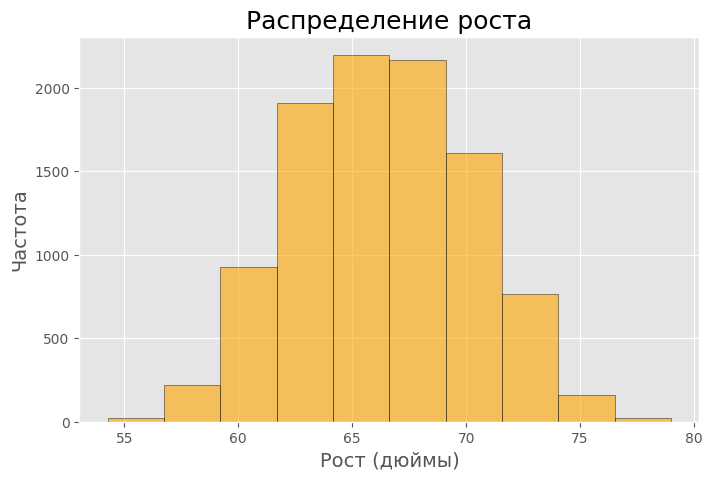

In [9]:
# Гистограмма для роста
df.Height.plot(kind='hist',
              color='orange', edgecolor='black', alpha=0.6,
              figsize=(8, 5))
plt.title('Распределение роста', size=18)
plt.xlabel('Рост (дюймы)', size=14)
plt.ylabel('Частота', size=14)
plt.show()

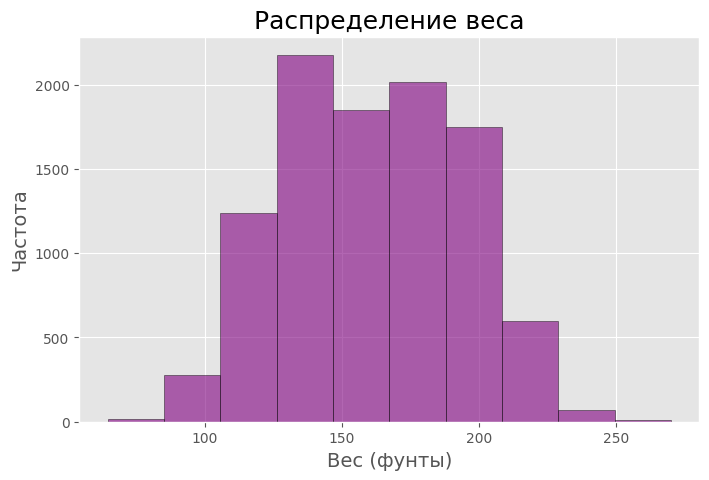

In [10]:
# Гистограмма для веса
df.Weight.plot(kind='hist',
              color='purple', edgecolor='black', alpha=0.6,
              figsize=(8, 5))
plt.title('Распределение веса', size=18)
plt.xlabel('Вес (фунты)', size=14)
plt.ylabel('Частота', size=14)
plt.show()

Гистограммы имеют нормальное распределение. Также, можно выявить зависимость, что, чем выше человек, тем он тяжелее.

Нормальное распределение говорит нам о том, что наименьшие и наибольшие значения роста и веса встречаются крайне редко.

Разделим гистограммы по гендеру

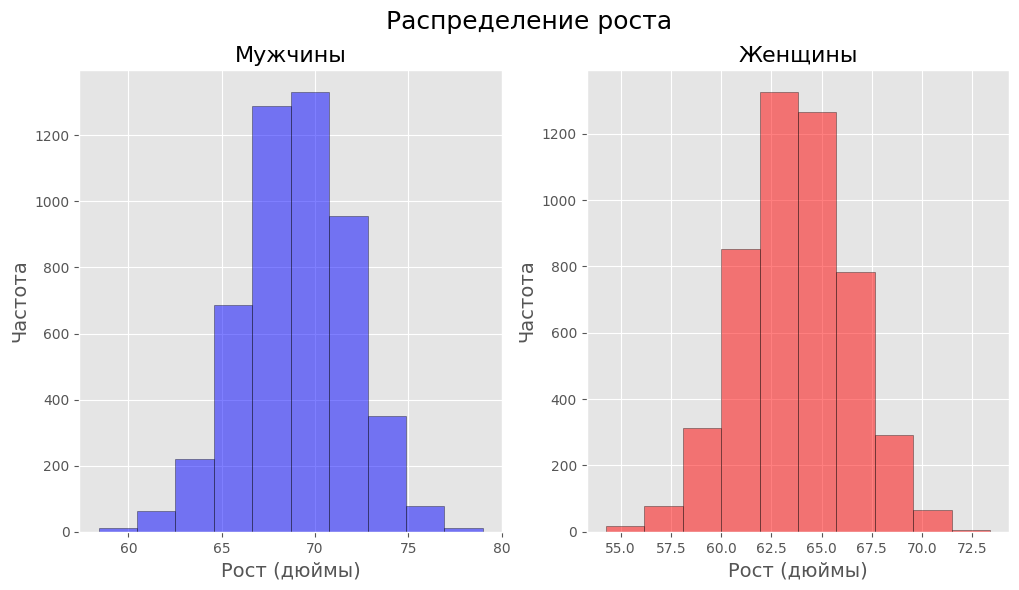

In [11]:
# Гистограмма для роста мужчин и женщин
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
df[df['Gender'] == 'Male'].Height.plot(kind='hist',
                                       color='blue',
                                       edgecolor='black',
                                       alpha=0.5,
                                       ax=ax1)

df[df['Gender'] == 'Female'].Height.plot(kind='hist',
                                         color='red',
                                         edgecolor='black',
                                         alpha=0.5,
                                         ax=ax2)
plt.suptitle('Распределение роста', size=18)
ax1.set_title('Мужчины', size=16)
ax1.set_xlabel('Рост (дюймы)', size=14)
ax1.set_ylabel('Частота', size=14)
ax2.set_title('Женщины', size=16)
ax2.set_xlabel('Рост (дюймы)', size=14)
ax2.set_ylabel('Частота', size=14)
plt.show()

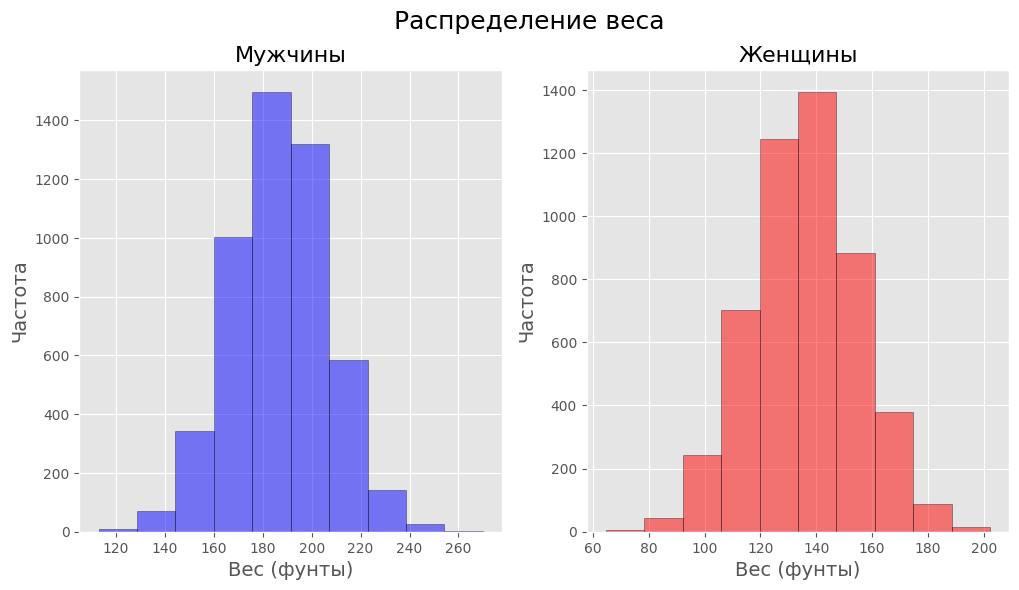

In [12]:
# Гистограмма для веса мужчин и женщин
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
df[df['Gender'] == 'Male'].Weight.plot(kind='hist',
                                       color='blue',
                                       edgecolor='black',
                                       alpha=0.5,
                                       ax=ax1)

df[df['Gender'] == 'Female'].Weight.plot(kind='hist',
                                         color='red',
                                         edgecolor='black',
                                         alpha=0.5,
                                         ax=ax2)
plt.suptitle('Распределение веса', size=18)
ax1.set_title('Мужчины', size=16)
ax1.set_xlabel('Вес (фунты)', size=14)
ax1.set_ylabel('Частота', size=14)
ax2.set_title('Женщины', size=16)
ax2.set_xlabel('Вес (фунты)', size=14)
ax2.set_ylabel('Частота', size=14)
plt.show()

Графики показывают, что рост и вес имеют нормальное распределение для мужчин и женщин. 

Выделим отдельно статистику по гендерам и выведем её общим фреймом

In [13]:
# Статистика по мужчинам
statistics_male = df[df['Gender'] == 'Male'].describe()
statistics_male.rename(columns=lambda x: x + '_male', inplace=True)

# Статистика по женщинам
statistics_female = df[df['Gender'] == 'Female'].describe()
statistics_female.rename(columns=lambda x: x + '_female', inplace=True)

# Общая статтистика
statistics = pd.concat([statistics_male, statistics_female], axis=1)
statistics

,Height_male,Weight_male,Height_female,Weight_female
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,69.026346,187.020621,63.708774,135.860093
std,2.863362,19.781155,2.696284,19.022468
min,58.406905,112.902939,54.263133,64.700127
25%,67.174679,173.887767,61.894441,122.934096
50%,69.027709,187.033546,63.730924,136.117583
75%,70.988744,200.357802,65.563565,148.810926
max,78.998742,269.989699,73.389586,202.237214


Значения показателей мы можем отобразить в форме точек с помощью точечного графика.
Но если вывести все 10 000 точек на одном полотне, то произвойдёт перекрытие, и мы не сможем ничего разглядеть.

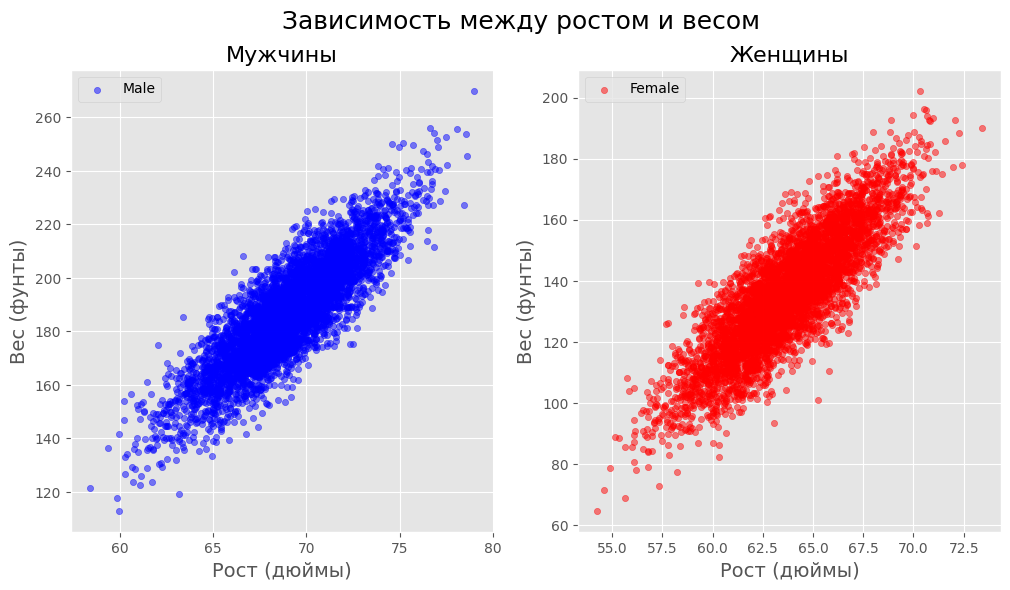

In [14]:
fig_, (ax_1, ax_2) = plt.subplots(1, 2, figsize=(12,6))
ax_1 = df[df['Gender'] == 'Male'].plot(kind='scatter',
                                       x='Height',
                                       y='Weight',
                                       color='blue',
                                       alpha=0.5,
                                       ax=ax_1)

ax_2 = df[df['Gender'] == 'Female'].plot(kind='scatter',
                                       x='Height',
                                       y='Weight',
                                       color='red',
                                       alpha=0.5,
                                       ax=ax_2)

ax_1.set_title('Мужчины', size=16)
ax_1.set_xlabel('Рост (дюймы)', size=14)
ax_1.set_ylabel('Вес (фунты)', size=14)
ax_1.legend(['Male'])

ax_2.set_title('Женщины', size=16)
ax_2.set_xlabel('Рост (дюймы)', size=14)
ax_2.set_ylabel('Вес (фунты)', size=14)
ax_2.legend(['Female'])
plt.suptitle('Зависимость между ростом и весом', size=18)

plt.show()

Полученные графики всё равно имеют довольно сильное перекрытие, поэтому мы можем взять отдельную выборку из 500 случайных записей

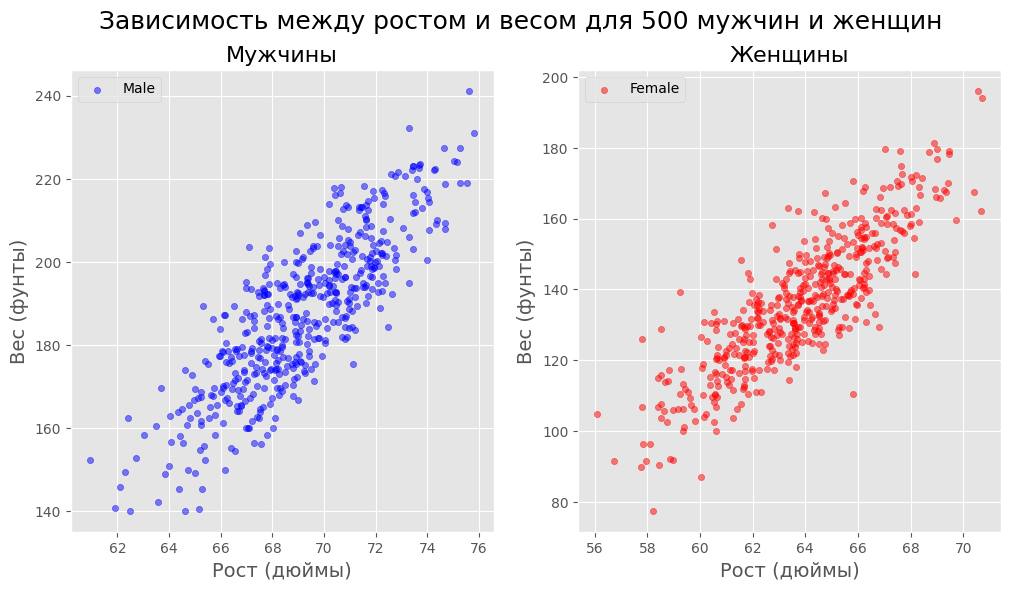

In [15]:
fig_, (ax_1, ax_2) = plt.subplots(1, 2, figsize=(12,6))
ax_1 = df[df['Gender'] == 'Male'].sample(500).plot(kind='scatter',
                                       x='Height',
                                       y='Weight',
                                       color='blue',
                                       alpha=0.5,
                                       ax=ax_1)

ax_2 = df[df['Gender'] == 'Female'].sample(500).plot(kind='scatter',
                                       x='Height',
                                       y='Weight',
                                       color='red',
                                       alpha=0.5,
                                       ax=ax_2)

ax_1.set_title('Мужчины', size=16)
ax_1.set_xlabel('Рост (дюймы)', size=14)
ax_1.set_ylabel('Вес (фунты)', size=14)
ax_1.legend(['Male'])

ax_2.set_title('Женщины', size=16)
ax_2.set_xlabel('Рост (дюймы)', size=14)
ax_2.set_ylabel('Вес (фунты)', size=14)
ax_2.legend(['Female'])
plt.suptitle('Зависимость между ростом и весом для 500 мужчин и женщин', size=18)

plt.show()

Как видно на графиках, вес мужчин и женщин возрастает с увеличением роста. 

Вычислим простую линейную регрессию, которая описывает отношения между двумя переменными с помощью линейного уравнения, с использованием библиотеки NumPy


Нам необходимо построить такую линию, которая лучше всего соответствует исходным данным и при этом минимизирует сумму квадратичных ошибок 

In [16]:
# Наилучшее приблежение полином
df_males = df[df['Gender'] == 'Male']
df_females = df[df['Gender'] == 'Female']

# Полином для мужчин
male_fit = np.polyfit(x=df_males.Height, y=df_males.Weight, deg=1)

# Полином для женщим
female_fit = np.polyfit(x=df_females.Height, y=df_females.Weight, deg=1)

# Возвращаются коэффициенты (b, a)
print(f'Мужчины: a = {male_fit[1]}, b = {male_fit[0]}')
print(f'Женщины: a = {female_fit[1]}, b = {female_fit[0]}')

Мужчины: a = -224.4988407054584, b = 5.961773812027686
Женщины: a = -246.0132657466725, b = 5.994046614854493


Здесь параметр deg отвечает за степень полинома (многочлена).

Так как мы строим линейную регрессию, то у нас должен быть многочлен первой степени.

Отобразим наш точечный график вместе с полученной линейной регрессией

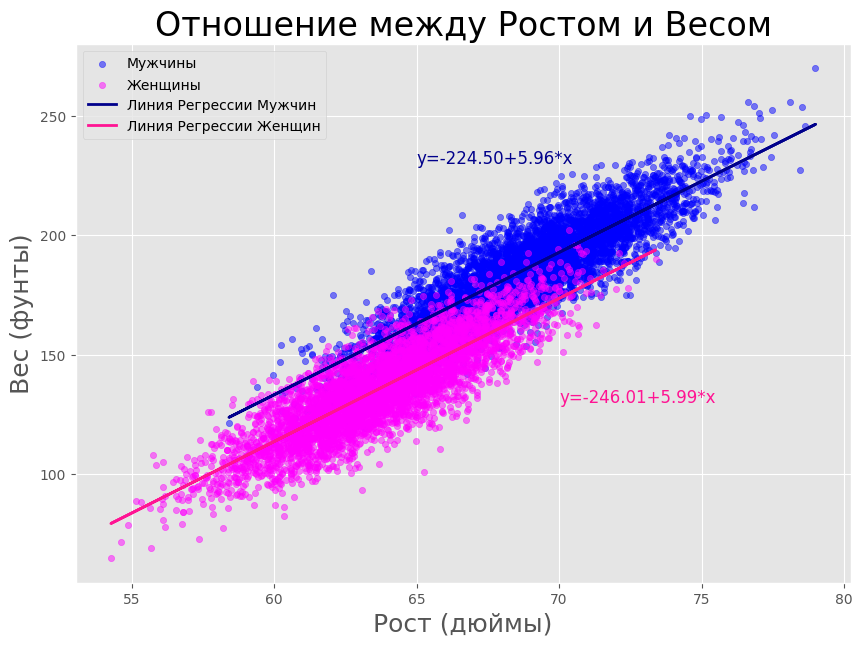

In [17]:
ax1 = df_males.plot(kind='scatter', x='Height', y='Weight', color='blue', alpha=0.5,
                    figsize=(10, 7))
df_females.plot(kind='scatter', x='Height', y='Weight', color='magenta', alpha=0.5,
                    figsize=(10, 7), ax=ax1)

# Линии регрессии
plt.plot(df_males.Height, male_fit[0]*df_males.Height+male_fit[1], color='darkblue', linewidth=2)
plt.plot(df_females.Height, female_fit[0]*df_females.Height+female_fit[1], color='deeppink', linewidth=2)

# Формула регрессии
plt.text(65, 230, 'y={:.2f}+{:.2f}*x'.format(male_fit[1], male_fit[0]), color='darkblue', size=12)
plt.text(70, 130, 'y={:.2f}+{:.2f}*x'.format(female_fit[1], female_fit[0]), color='deeppink', size=12)

# Легенда, название, оси
plt.legend(labels=['Мужчины', 'Женщины', 'Линия Регрессии Мужчин', 'Линия Регрессии Женщин'])
plt.title('Отношение между Ростом и Весом', size=24)
plt.xlabel('Рост (дюймы)', size=18)
plt.ylabel('Вес (фунты)', size=18)

plt.show()

Построим график с регрессией, используя библиотеку Seaborn, основанную на Matplotlib

Чтобы отключить доверительный интервал - полупрозрачную область, прописал атрибут ci=None

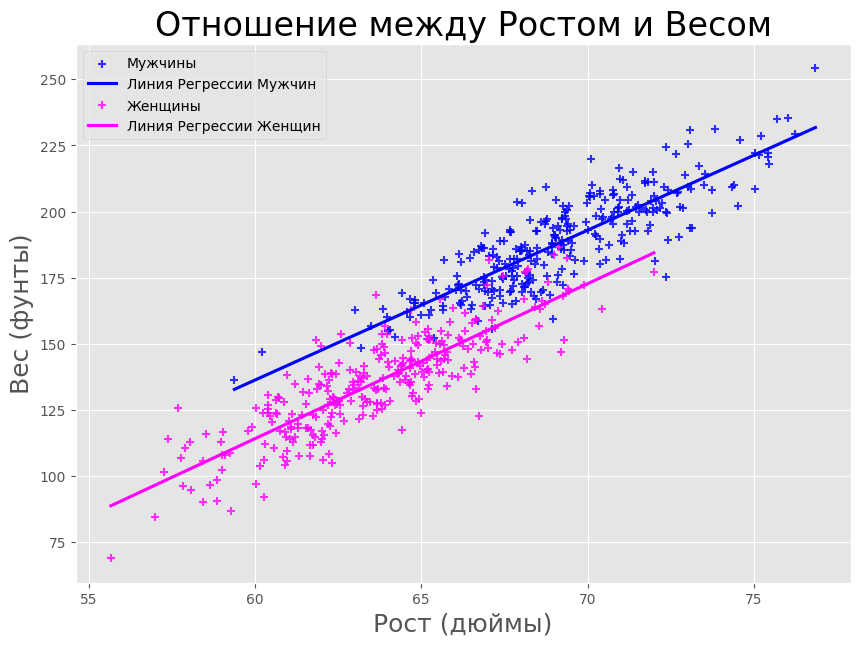

In [18]:
# Выборка
df_males_sample = df_males.sample(300)
df_females_sample = df_females.sample(300)

# График регрессии
fig = plt.figure(figsize=(10,7))
sns.regplot(x=df_males_sample.Height,
            y=df_males_sample.Weight,
            color='blue', marker='+', ci=None)

sns.regplot(x=df_females_sample.Height,
            y=df_females_sample.Weight,
            color='magenta', marker='+', ci=None)

plt.legend(labels=['Мужчины', 'Линия Регрессии Мужчин', 'Женщины', 'Линия Регрессии Женщин', 'girl'])
plt.title('Отношение между Ростом и Весом', size=24)
plt.xlabel('Рост (дюймы)', size=18)
plt.ylabel('Вес (фунты)', size=18)

plt.show()

Теперь подгоним модель с использованием специализированной библиотеки.

Для это из библиотеки sklear импортируем класс Линейной регрессии.

In [19]:
from sklearn.linear_model import LinearRegression

lr_males = LinearRegression()
lr_males.fit(df_males[['Height']], df_males[['Weight']])

print(f'Мужчины, a: {lr_males.intercept_[0]}, b:{lr_males.coef_[0]}')

lr_females = LinearRegression()
lr_females.fit(df_females[['Height']], df_females[['Weight']])

print(f'Женщины, a: {lr_females.intercept_[0]}, b:{lr_females.coef_[0]}')

Мужчины, a: -224.49884070545863, b:[5.96177381]
Женщины, a: -246.01326574667254, b:[5.99404661]


После подгона модели можно построить функцию для прогнозирования веса по росту.

У нас есть по две модели для каждого пола: есть линейная регрессия, которая подгонялась через NumPy, а есть, которая подгонялась с помощью Sklearn

In [20]:
# Прогнозирование с помощью NumPy
print(f'Прогнозирование для мужчины с помощью NumPy: {np.polyval(male_fit, 60)}')
print(f'Прогнозирование для женщины с помощью NumPy: {np.polyval(female_fit, 60)}')
# Прогнозирование с помощью Sklearn
print(f'Прогнозирование для мужчины с помощью Sklearn: {lr_males.predict([[60]])[0]}')
print(f'Прогнозирование для женщины с помощью Sklearn: {lr_females.predict([[60]])[0]}')

Прогнозирование для мужчины с помощью NumPy: 133.20758801620275
Прогнозирование для женщины с помощью NumPy: 113.62953114459705
Прогнозирование для мужчины с помощью Sklearn: [133.20758802]
Прогнозирование для женщины с помощью Sklearn: [113.62953114]


Также мы можем выявить силу и направление отношений между двумя переменными, которую называют коэффициентом корреляции Пирсона.

Для этого можно воспользоваться как библиотекой Pandas, так и Sklearn

In [21]:
# Коэффициент корреляции Пирсона. Pandas
# Женщины
df_females_cor = df_females.iloc[:, 1:]
print('Females')
df_females_cor.corr()

Females


,Height,Weight
Height,1.000000,0.849609
Weight,0.849609,1.000000


In [22]:
# Коэффициент корреляции Пирсона. Pandas
# Мужчины
df_males_cor = df_males.iloc[:, 1:]
print('Males')
df_males_cor.corr()

Males


,Height,Weight
Height,1.000000,0.862979
Weight,0.862979,1.000000


In [23]:
# Коэффициент корреляции Пирсона. Sklearn
pearson_coef_f, p_value_f = stats.pearsonr(df_females.Height, df_females.Weight)
print(f'Коэффициент для женщин: {pearson_coef_f}')

pearson_coef_m, p_value_m = stats.pearsonr(df_males.Height, df_males.Weight)
print(f'Коэффициент для мужчин: {pearson_coef_m}')

Коэффициент для женщин: 0.8496085914186009
Коэффициент для мужчин: 0.8629788486163174


Таким образом, коэффициент корреляции с помощью Pandas и с помощью SciPy совпали.

По значениям видно, что между переменными роста и веса очень сильные линейные отношения.

Мы выполнили оценку, можно ли выполнять прогнозирование данных с помощью модели, построенной на основе линейной регрессии,
с помощью выявления линейной зависимости переменных. Но есть и другой способ.

Вторым способом является использование остаточных участков. Они показывают разницу между фактическими и прогнозируемыми значениями.

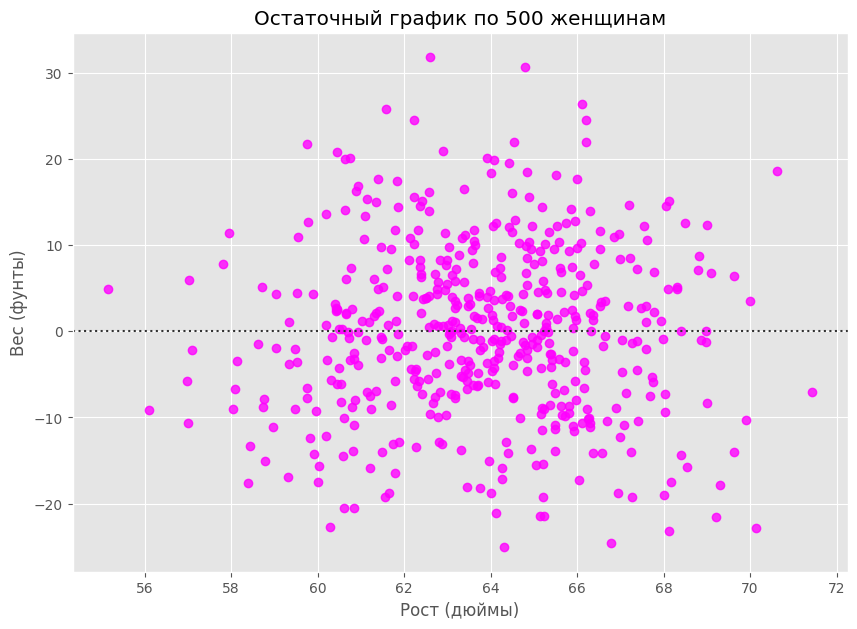

In [24]:
# Женщины
df_females_sample = df_females.sample(500)

fig = plt.figure(figsize=(10, 7))
sns.residplot(x=df_females_sample.Height,
              y=df_females_sample.Weight,
              color='magenta')

plt.title('Остаточный график по 500 женщинам')
plt.xlabel('Рост (дюймы)')
plt.ylabel('Вес (фунты)')

plt.show()

По графику видно, что значения распределены вокруг нуля, что означает, что линейная регрессионная модель подходит для прогнозирования данных.

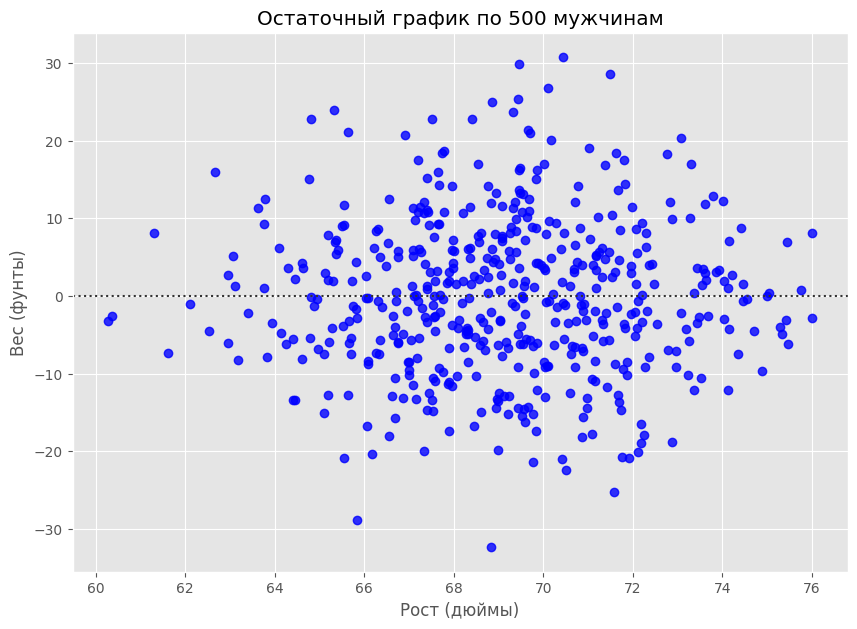

In [25]:
# Мужчины
df_males_sample = df_males.sample(500)

fig = plt.figure(figsize=(10, 7))
sns.residplot(x=df_males_sample.Height,
              y=df_males_sample.Weight,
              color='blue')

plt.title('Остаточный график по 500 мужчинам')
plt.xlabel('Рост (дюймы)')
plt.ylabel('Вес (фунты)')

plt.show()

Для мужчин ситуация аналогична

# *Раздел II. Множественная линейная регрессия*

## *Цель исследования:*

Определить стоимость на недвижимость в зависимость от её местоположения, числа комнат, типа дома и площадей жилья.

### *Задачи:*
* Выявить зависимость стоимости от параметров;
* Построить модель множественной линейной регрессии;
* Предсказать стоимость некоторой выборки недвижимости;
* Оценить модель несколькими способами.

В файле заменил значения с лишними пробелами с помощью Microsoft Excel

In [26]:
# Импортирование библиотек

In [27]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [28]:
# Чтение файла
df = pd.read_excel('data/nedvig.xlsx')
df

,Район,Число комнат,Тип дома,Общая,Жилая,Кухня,"Цена, тыс. руб."
0,ЮМР,1,блочный,40.0,20.0,10.0,1596.0
1,ЮМР,2,блочный,60.0,32.0,10.0,1876.0
2,ЮМР,2,блочный,77.0,40.0,16.0,3500.0
3,ЮМР,3,блочный,66.0,42.0,9.0,2074.8
4,ЮМР,3,блочный,70.0,44.0,10.0,2156.0
...,...,...,...,...,...,...,...
1568,ФМР,2,кирпичный,156.7,101.1,12.0,7290.0
1569,Центр,2,кирпичный,162.0,86.0,13.0,5670.0
1570,Центр,3,кирпичный,166.0,98.0,25.0,6210.0
1571,ЮМР,4,кирпичный,177.0,36.0,14.0,4590.0


In [29]:
print(df.head())
print(df.shape)
print(df.dtypes)
print(df.info())
print(df.nunique())
print(df.isna().sum())

  Район  Число комнат Тип дома  Общая  Жилая  Кухня  Цена, тыс. руб.
0   ЮМР             1  блочный   40.0   20.0   10.0           1596.0
1   ЮМР             2  блочный   60.0   32.0   10.0           1876.0
2   ЮМР             2  блочный   77.0   40.0   16.0           3500.0
3   ЮМР             3  блочный   66.0   42.0    9.0           2074.8
4   ЮМР             3  блочный   70.0   44.0   10.0           2156.0
(1573, 7)
Район                  str
Число комнат         int64
Тип дома               str
Общая              float64
Жилая              float64
Кухня              float64
Цена, тыс. руб.    float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 1573 entries, 0 to 1572
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Район            1573 non-null   str    
 1   Число комнат     1573 non-null   int64  
 2   Тип дома         1573 non-null   str    
 3   Общая            1573 non-null   float64
 4

В таблице присутствуют 2 столбца с пропущенными значениями. Нужно заменить их на значения, равные математическому ожиданию.

In [30]:
df[['Жилая', 'Кухня']] = df[['Жилая', 'Кухня']].apply(lambda x: x.fillna(x.mean()))
print(df.isna().sum())

Район              0
Число комнат       0
Тип дома           0
Общая              0
Жилая              0
Кухня              0
Цена, тыс. руб.    0
dtype: int64


В таблице содержится 1573 строки и 7 столбцов. Данный набор представляет собой зафиксированные параметры квартир, куда вошли и район расположения недвижимости - всего их 23 и представлены в виде категориальных данных; ещё в таком виде представлен тип дома, из числовых данных здесь описаны: число комнат - 5 разных значений, общая площадь, жилая площадь и площадь кухни. В последнем столбце содержится стоимость этой недвижимости в тыс. рублей.

Посмотрим распределение категориальных данных по столбцу с типом домов.

In [31]:
# Выведем все типы домов и колчи

df['Тип дома'].value_counts()

Тип дома
блочный       663
кирпичный     527
каркасный     365
монолитный      9
панельный       9
Name: count, dtype: int64

Построим описательную статистику наиболее численных категорий.

In [32]:
stat_block = df[df['Тип дома'] == "блочный"].describe()
stat_block.rename(columns=lambda x: x + "_bl", inplace=True)

stat_brick =df[df['Тип дома'] == "кирпичный"].describe()
stat_brick.rename(columns=lambda x: x + "_br", inplace=True)

stat_const =df[df['Тип дома'] == "каркасный"].describe()
stat_const.rename(columns=lambda x: x + "_const", inplace=True)

statistic = pd.concat([stat_block, stat_brick, stat_const], axis=1)
statistic

,Число комнат_bl,Общая_bl,Жилая_bl,Кухня_bl,"Цена, тыс. руб._bl",Число комнат_br,Общая_br,Жилая_br,Кухня_br,"Цена, тыс. руб._br",Число комнат_const,Общая_const,Жилая_const,Кухня_const,"Цена, тыс. руб._const"
count,663.000000,663.000000,663.000000,663.000000,663.000000,527.000000,527.000000,527.000000,527.000000,527.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2.453997,63.264781,37.675783,10.051473,2079.313897,2.392789,61.983700,35.943643,10.508729,2061.304176,2.164384,63.295342,38.259178,9.909041,2092.625753
std,0.966467,25.275664,16.267570,4.261802,1786.860964,1.058815,26.326342,17.671100,3.905008,960.304051,1.188471,26.363172,16.815704,4.198364,970.823206
min,1.000000,21.000000,13.000000,1.000000,270.000000,1.000000,11.000000,8.000000,0.000000,561.600000,1.000000,23.000000,12.000000,2.600000,657.990000
25%,2.000000,45.000000,27.000000,7.000000,1448.550000,2.000000,42.000000,20.000000,8.000000,1429.650000,1.000000,43.000000,26.000000,6.700000,1485.000000
50%,2.000000,60.000000,35.000000,9.000000,1800.000000,2.000000,60.000000,32.000000,10.000000,1800.000000,2.000000,60.000000,38.000000,9.000000,1899.990000
75%,3.000000,72.000000,44.200000,12.000000,2311.200000,3.000000,72.400000,44.000000,13.000000,2486.600000,3.000000,77.000000,46.000000,12.000000,2397.600000
max,5.000000,226.000000,120.000000,44.000000,41706.898000,5.000000,205.000000,110.000000,26.000000,7290.000000,7.000000,204.000000,111.000000,32.000000,10260.000000


### Построим графики

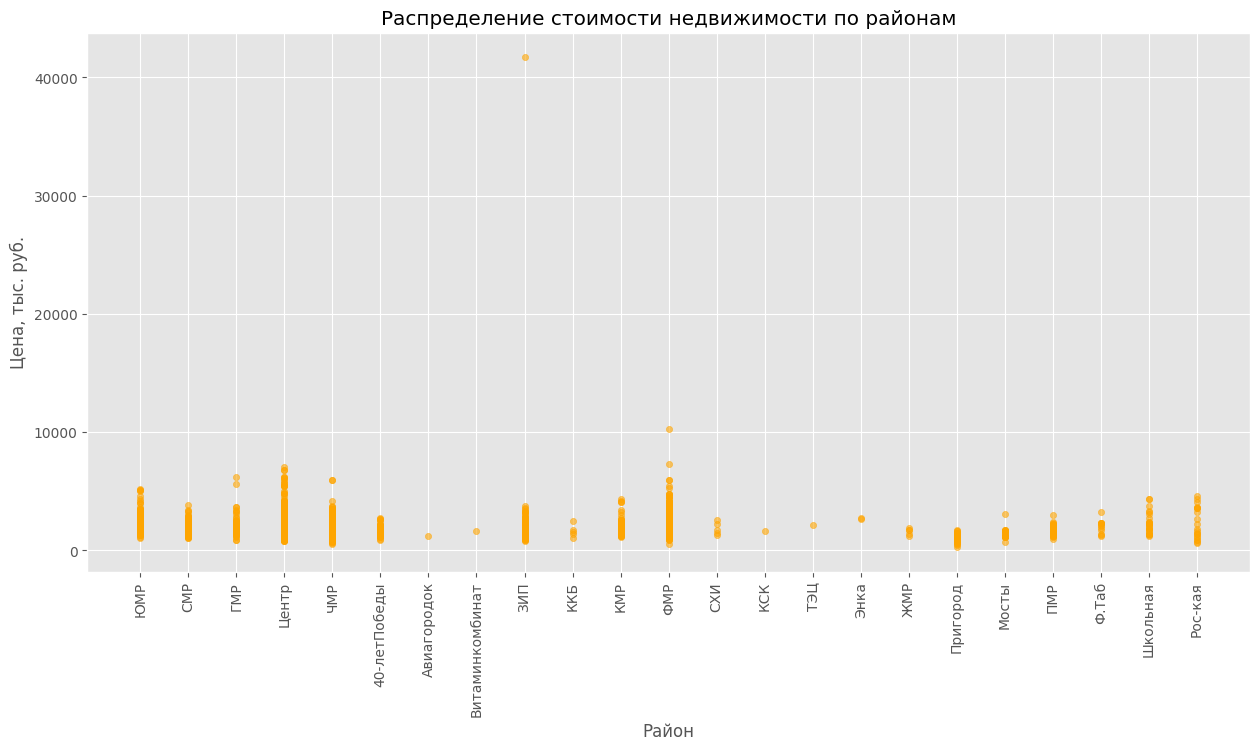

In [33]:
# Распределение стоимости по району
ax1 = df.plot(kind='scatter',
              x='Район', y='Цена, тыс. руб.',
              color = 'orange', alpha=0.6,
              figsize=(15, 7))

plt.xticks(rotation=90)
plt.title("Распределение стоимости недвижимости по районам")
plt.show()

Построим некоторые гистограммы.

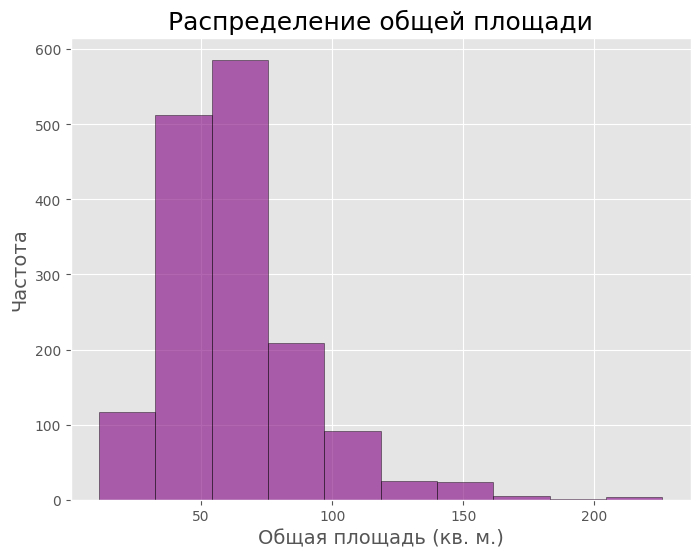

In [34]:
# Распределение общей площади
df['Общая'].plot(kind='hist',
        color='purple', edgecolor='black', alpha=0.6,
        figsize=(8, 6))

plt.title('Распределение общей площади', size=18)
plt.xlabel('Общая площадь (кв. м.)', size=14)
plt.ylabel('Частота', size=14)
plt.show()

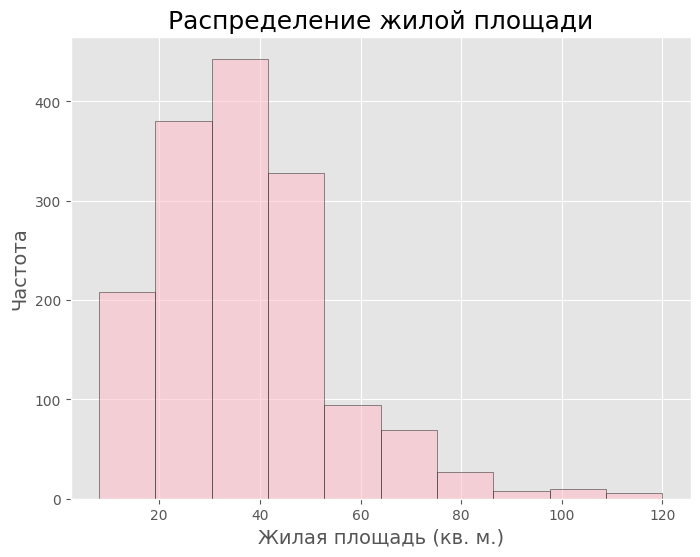

In [35]:
# Распределение жилой площади
df['Жилая'].plot(kind='hist',
        color='pink', edgecolor='black', alpha=0.6,
        figsize=(8, 6))

plt.title('Распределение жилой площади', size=18)
plt.xlabel('Жилая площадь (кв. м.)', size=14)
plt.ylabel('Частота', size=14)
plt.show()

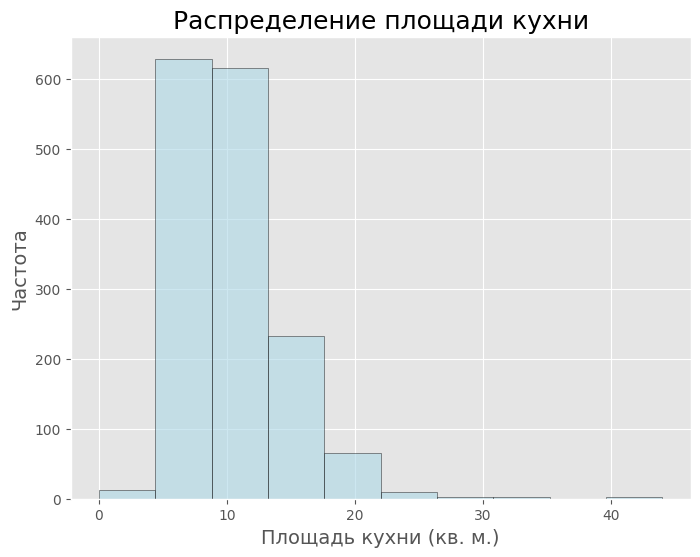

In [36]:
# Распределение площади кухни
df['Кухня'].plot(kind='hist',
        color='lightblue', edgecolor='black', alpha=0.6,
        figsize=(8, 6))

plt.title('Распределение площади кухни', size=18)
plt.xlabel('Площадь кухни (кв. м.)', size=14)
plt.ylabel('Частота', size=14)
plt.show()

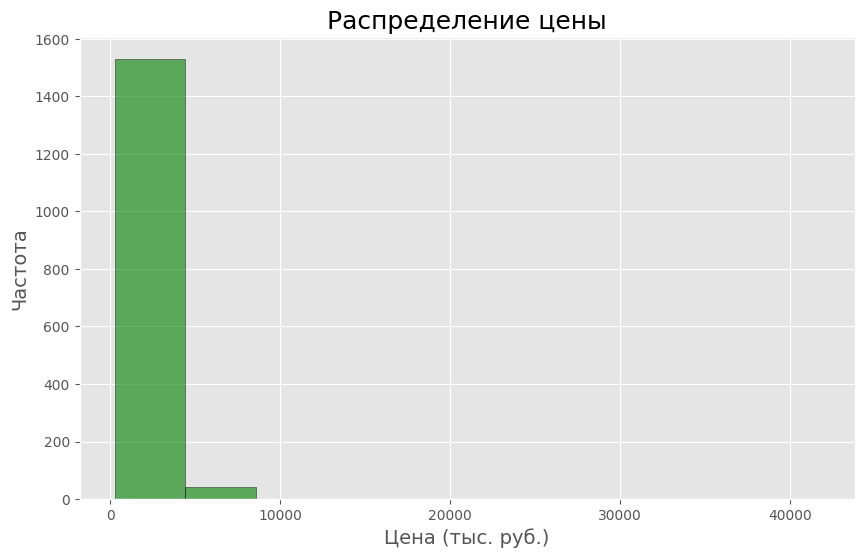

In [37]:
# Распределение цены
df['Цена, тыс. руб.'].plot(kind='hist',
        color='green', edgecolor='black', alpha=0.6,
        figsize=(10, 6))

plt.title('Распределение цены', size=18)
plt.xlabel('Цена (тыс. руб.)', size=14)
plt.ylabel('Частота', size=14)
plt.show()

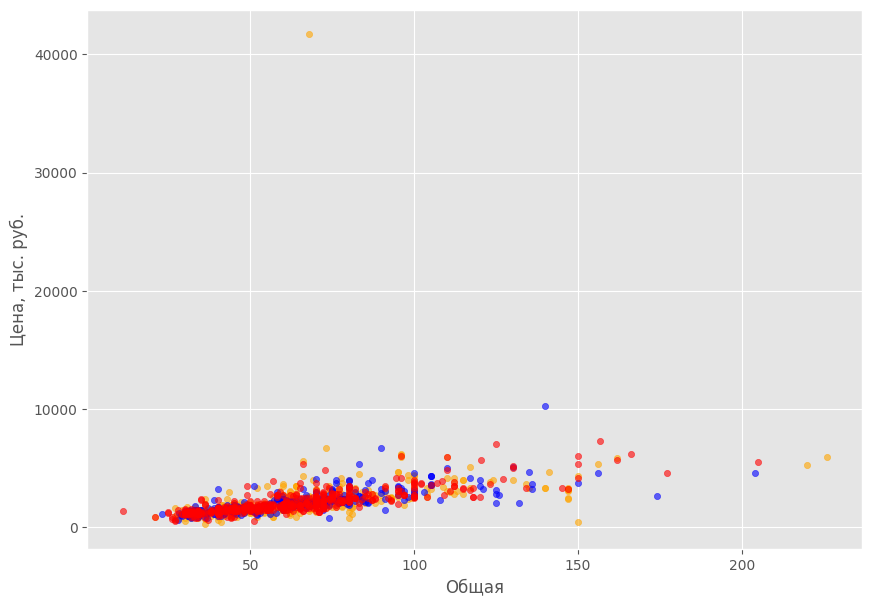

In [38]:
# Распределение стоимости по общей площади
ax1 = df[df['Тип дома'] == 'блочный'].plot(kind='scatter',
              x='Общая', y='Цена, тыс. руб.',
              color = 'orange', alpha=0.6,
              figsize=(10, 7))

df[df['Тип дома'] == 'каркасный'].plot(kind='scatter',
              x='Общая', y='Цена, тыс. руб.',
              color = 'blue', alpha=0.6,
              figsize=(10, 7), ax=ax1)

df[df['Тип дома'] == 'кирпичный'].plot(kind='scatter',
              x='Общая', y='Цена, тыс. руб.',
              color = 'red', alpha=0.6,
              figsize=(10, 7), ax=ax1)

plt.show()

На графике видно, что есть одно значение, которое очень сильно отдалено от остальных точек, поэтому найдем строку и удалим её из датасета.

In [39]:
print(df[df['Цена, тыс. руб.'] == df['Цена, тыс. руб.'].max()])

    Район  Число комнат Тип дома  Общая  Жилая  Кухня  Цена, тыс. руб.
146   ЗИП             2  блочный   68.0   33.0   16.0        41706.898


In [40]:
# Удаление
df.drop(index=146, inplace=True)
df.reset_index(drop=True, inplace=True)

# Проверка
print(df[df['Цена, тыс. руб.'] == df['Цена, тыс. руб.'].max()])

     Район  Число комнат   Тип дома  Общая  Жилая  Кухня  Цена, тыс. руб.
1032   ФМР             2  каркасный  140.0   83.0   28.0          10260.0


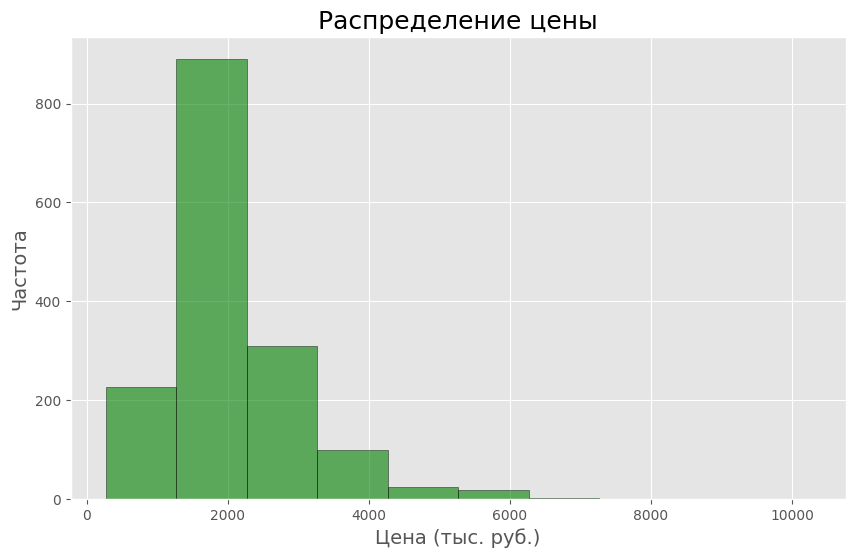

In [41]:
# Новое распределение цены
df['Цена, тыс. руб.'].plot(kind='hist',
        color='green', edgecolor='black', alpha=0.6,
        figsize=(10, 6))

plt.title('Распределение цены', size=18)
plt.xlabel('Цена (тыс. руб.)', size=14)
plt.ylabel('Частота', size=14)
plt.show()

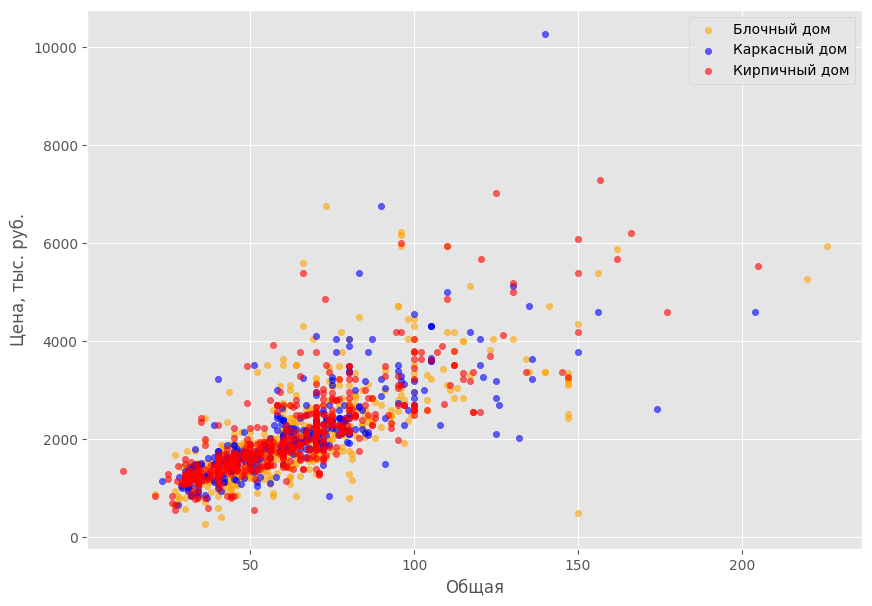

In [42]:
# Новое распределение стоимости по общей площади
ax1 = df[df['Тип дома'] == 'блочный'].plot(kind='scatter',
              x='Общая', y='Цена, тыс. руб.',
              color = 'orange', alpha=0.6,
              figsize=(10, 7))

df[df['Тип дома'] == 'каркасный'].plot(kind='scatter',
              x='Общая', y='Цена, тыс. руб.',
              color = 'blue', alpha=0.6,
              figsize=(10, 7), ax=ax1)

df[df['Тип дома'] == 'кирпичный'].plot(kind='scatter',
              x='Общая', y='Цена, тыс. руб.',
              color = 'red', alpha=0.6,
              figsize=(10, 7), ax=ax1)

plt.legend(labels=['Блочный дом', 'Каркасный дом', 'Кирпичный дом'])
plt.show()

Посмотрим, как стоимость распределяется в зависимости от других числовых параметров: таких, как число комнат, жилая площадь, площадь кухни.

In [43]:
numeric_col = df.select_dtypes(include=['int', 'float64']).columns
df[numeric_col].corr()

,Число комнат,Общая,Жилая,Кухня,"Цена, тыс. руб."
Число комнат,1.000000,0.183988,0.197150,0.046710,0.197152
Общая,0.183988,1.000000,0.905595,0.540106,0.773570
Жилая,0.197150,0.905595,1.000000,0.343169,0.722725
Кухня,0.046710,0.540106,0.343169,1.000000,0.441914
"Цена, тыс. руб.",0.197152,0.773570,0.722725,0.441914,1.000000


Согласно матрице корреляции Пирсона, мы можем использовать число комнат, общую площадь, жилую площадь и площадь кухни в качестве независимых переменных. Но между общей и жилой площадями сильная линейная связь, то есть присутствует высокий риск мультиколлинеарности. Поэтому следует удалить один из них - это будет столбец "Жилая".

In [44]:
df.pop('Жилая')
df

,Район,Число комнат,Тип дома,Общая,Кухня,"Цена, тыс. руб."
0,ЮМР,1,блочный,40.0,10.0,1596.0
1,ЮМР,2,блочный,60.0,10.0,1876.0
2,ЮМР,2,блочный,77.0,16.0,3500.0
3,ЮМР,3,блочный,66.0,9.0,2074.8
4,ЮМР,3,блочный,70.0,10.0,2156.0
...,...,...,...,...,...,...
1567,ФМР,2,кирпичный,156.7,12.0,7290.0
1568,Центр,2,кирпичный,162.0,13.0,5670.0
1569,Центр,3,кирпичный,166.0,25.0,6210.0
1570,ЮМР,4,кирпичный,177.0,14.0,4590.0


Определим все категориальные данные и преобразуем их с помощью класса OneHotEncoder, импортированного из библиотеки sklearn.

In [45]:
categorical_cols = df.select_dtypes(include=['object']).columns

encoder = OneHotEncoder()

encoded_categorical = encoder.fit_transform(df[categorical_cols])
header = encoder.get_feature_names_out(categorical_cols)
df_encoded = pd.DataFrame(encoded_categorical.toarray(), columns=header)

df_mlr = pd.concat([df.drop(categorical_cols, axis=1), df_encoded], axis=1)
df_mlr

,Число комнат,Общая,Кухня,"Цена, тыс. руб.",Район_40-летПобеды,Район_Авиагородок,Район_Витаминкомбинат,Район_ГМР,Район_ЖМР,Район_ЗИП,...,Район_Центр,Район_ЧМР,Район_Школьная,Район_Энка,Район_ЮМР,Тип дома_блочный,Тип дома_каркасный,Тип дома_кирпичный,Тип дома_монолитный,Тип дома_панельный
0,1,40.0,10.0,1596.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,2,60.0,10.0,1876.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,2,77.0,16.0,3500.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,3,66.0,9.0,2074.8,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,3,70.0,10.0,2156.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1567,2,156.7,12.0,7290.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1568,2,162.0,13.0,5670.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1569,3,166.0,25.0,6210.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1570,4,177.0,14.0,4590.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


Разделим данные на наборы для обучения и тестирования

In [46]:
X_train, X_test, y_train, y_test = train_test_split(df_mlr.drop('Цена, тыс. руб.', axis=1), df_mlr['Цена, тыс. руб.'], test_size=0.25, random_state=42)

Теперь мы можем построить модель.

Вызовем регрессор LinearRegression из библиотеки sklearn и передадим туда данные.

In [47]:
mlr = LinearRegression()

mlr.fit(X_train, y_train)

print(f'a: {mlr.intercept_}')
print(f'b0 - b30: {mlr.coef_}')

a: 160.27032012446944
b0 - b30: [ -32.95814935   27.56662269   10.26895134  -36.03909624  -71.01760406
    3.31616908   21.00471567 -173.74630729 -105.90958537 -192.14152626
  -57.84725299 -189.39190843   -9.61453824 -238.96968639 -628.76810228
 -325.88269691   10.75770425   27.93012018  -66.40289201   51.9108666
  226.46311035  436.05682056  132.74982495  151.80344433  818.66598627
  215.07243423  -11.64898759    5.01593577   10.46497987 -164.3639274
  160.53199935]


Теперь, после создания модели мы можем спрогнозировать стоимость недвижимости по независимым переменным из тестового набора. 

In [48]:
y_pred = mlr.predict(X_test)

Получив с помощью модели теоретические значения, мы можем сравнить их с действительными, которые содержатся в тестовом наборе.

Сначала оценим модель с помощью метода коэффициента детерминации, который показывает в долях, на сколько хорошо регрессионная модель соответствует реальным данным. Чем выше показатель, тем лучше.

In [49]:
r2 = r2_score(y_test, y_pred)

print(f"R2: {r2:.4f}")

R2: 0.6836


Оценка показала значение в 0.6836, что является типичным для моделей в области экономики. Но в целом для линейной регрессии такое значение является средним.

Дополнительно оценим модель с помощью других методов. Например,
* Метод средней абсолютной ошибки: измеряет среднее абсолютное отклонение между фактическими и прогнозируемыми значениями в наборе данных.
* Метод среднеквадратичной ошибки: показывает, насколько в среднем предсказания модели отклоняются от реальных значений.
* Корень из среднеквадратичной ошибки: Показывает среднюю величину ошибки

In [50]:
# Метод средней абсолютной ошибки 
mae = mean_absolute_error(y_test, y_pred)
print(f'MAE: {mae:.2f}')

# Метод среднеквадратичной ошибки
mse = mean_squared_error(y_test, y_pred)
print(f'MSE: {mse:.2f}')

# Корень из среднеквадратичной ошибки
rmse = np.sqrt(mse)
print(f'RMSE: {rmse:.2f}')

MAE: 353.90
MSE: 273345.15
RMSE: 522.82


В целом, модель получилась рабочей. Она способна объяснить большую часть зависимостей в данных. Модель определяет стоимость недвижимости с ошибкой в 353,9 тыс. руб, что может стать критичным в некоторых моментах. По оценке RMSE можно заметить, что в модели присутствуют выбросы, которые можно увидеть, исходя из разности между RMSE и MAE в 168,92 тыс. руб. Что касается улучшения, то в модель необходимо добавить параметры, по которым можно будет уточнить, почему стоимость недвижимости больше или меньше теоретического.